<a href="https://colab.research.google.com/github/Grupo-LCE0212/Estatistica/blob/main/semana04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Estatística - Python - Ciencias dos Alimentos

#Atividade da Semana

Nome: Iago Aparecido Dias dos Santos N​​° USP:16873011

Nome: João Pedro Paschoalini N​​° USP:17831089

Nome: Maria Eduarda Porta N° USP: 17074105

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

# Load the dataset
df = pd.read_csv('/content/fisico-quimicas.csv')

# Display the first few rows of the DataFrame
print('Primeiras 5 linhas do dataset:')
display(df.head())

# Display information about the DataFrame to check for missing values and data types
print('\nInformações do DataFrame:')
df.info()

Primeiras 5 linhas do dataset:


,Amostra,Categoria,Solidos_Soluveis_Brix,Acucar_g_100g,pH,Acidez_g_100mL,Acucar_estimado
0,A27,Frutas,14.12,9.42,2.86,0.65,8.706996
1,A05,Sucos e bebidas,10.02,7.17,2.83,0.79,5.552567
2,A60,Néctares e polpas,13.41,5.10,3.03,0.88,8.160741
3,A41,Néctares e polpas,23.37,15.14,2.90,0.45,15.823696
4,A10,Sucos e bebidas,7.71,5.05,2.99,0.79,3.775315



Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Amostra                60 non-null     object 
 1   Categoria              60 non-null     object 
 2   Solidos_Soluveis_Brix  60 non-null     float64
 3   Acucar_g_100g          60 non-null     float64
 4   pH                     60 non-null     float64
 5   Acidez_g_100mL         60 non-null     float64
 6   Acucar_estimado        60 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.4+ KB


## Análise da Relação entre Acidez e pH

### 1. Como a acidez das amostras se comporta em relação ao pH? Apresente um gráfico que permita visualizar essa relação.

Nos seus dados, temos 60 amostras. O pH varia aproximadamente de 2,67 até 3,23, enquanto a acidez varia de aproximadamente 0,41 até 0,92 g/100 mL.

Quando colocamos isso em um gráfico de dispersão, cada pontinho representa uma amostra. No eixo X colocamos o pH e no eixo Y colocamos a acidez.

O que acontece nos seus dados é o seguinte: existe uma leve tendência de aumento da acidez conforme o pH aumenta. Isso aparece porque a reta de regressão fica um pouco inclinada para cima.

A equação encontrada foi:

Acidez=0,2375+0,1511×pH

Esse 0,1511 positivo indica que a reta sobe. Portanto, matematicamente, nos seus dados, valores maiores de pH estão associados a valores ligeiramente maiores de acidez.

Mas aqui está a parte mais importante: essa tendência é muito fraca.

Os pontos do gráfico ficam bastante espalhados. Ou seja, você pode encontrar duas amostras com pH parecido, mas com valores de acidez bem diferentes. Isso mostra que o pH sozinho não consegue explicar muito bem por que algumas amostras têm maior ou menor acidez.

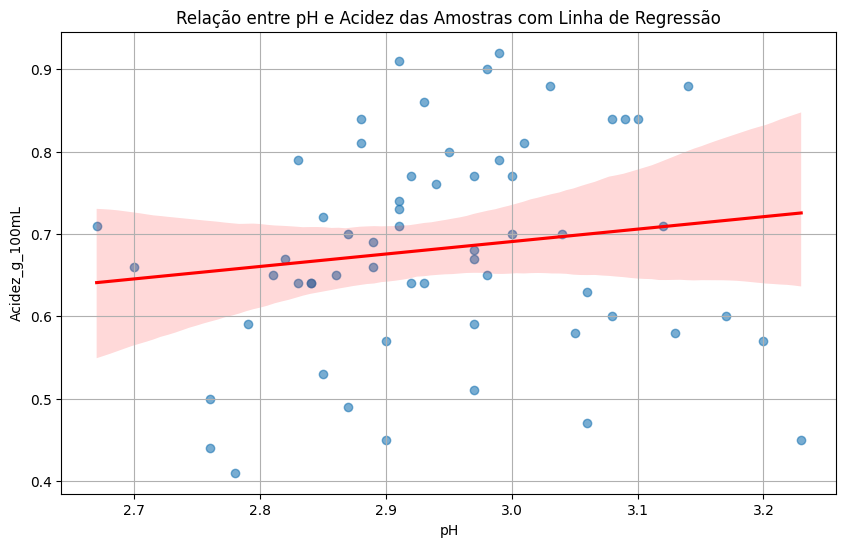

In [13]:
# Create a scatter plot to visualize the relationship between pH and Acidez, with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='pH', y='Acidez_g_100mL', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Relação entre pH e Acidez das Amostras com Linha de Regressão')
plt.xlabel('pH')
plt.ylabel('Acidez_g_100mL')
plt.grid(True)
plt.show()

### 2. Existe evidência de uma associação entre o pH e a acidez das amostras?

Nos seus dados, a correlação de Pearson foi aproximadamente:

r=0,141

Esse valor indica uma associação positiva, mas muito fraca, porque está bem perto de zero.

Só que, para saber se existe evidência estatística de associação, a gente olha também o p-valor. No seu caso:

p≈0,281

Agora vem a regra principal:

se p < 0,05, consideramos que há evidência estatística de associação;
se p > 0,05, não temos evidência estatística suficiente.

Como:

0,281 > 0,05

a conclusão é que não existe evidência estatística suficiente de associação linear entre o pH e a acidez nas amostras analisadas.

Isso não significa que seja impossível existir alguma relação entre essas variáveis. Significa apenas que, com esses dados, a relação linear observada é fraca demais para ser considerada estatisticamente significativa.

In [9]:
# Calculate the Pearson correlation coefficient between pH and Acidez
correlation, p_value = pearsonr(df['pH'], df['Acidez_g_100mL'])

print(f"Coeficiente de Correlação de Pearson entre pH e Acidez: {correlation:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < 0.05:
    print("Existe evidência estatística de uma associação significativa entre pH e Acidez.")
else:
    print("Não há evidência estatística de uma associação significativa entre pH e Acidez.")

Coeficiente de Correlação de Pearson entre pH e Acidez: 0.1413
Valor p: 0.2814
Não há evidência estatística de uma associação significativa entre pH e Acidez.


### 3. Como varia, em média, a acidez quando o pH aumenta em uma unidade?

No seu caso, a equação estimada foi:

Acidez=0,2375+0,1511×pH

O número mais importante aqui é o 0,1511. Ele é o coeficiente angular da reta.

Isso significa que, em média, quando o pH aumenta 1 unidade, a acidez aumenta cerca de 0,151 g/100 mL.

Por exemplo, se o pH passasse de 2,0 para 3,0, o modelo estimaria um aumento médio de aproximadamente:

0,151 g/100 mL

E se passasse de 3,0 para 4,0, novamente o modelo estimaria um aumento médio de cerca de 0,151 g/100 mL.

O termo “em média” é importante porque isso não quer dizer que todas as amostras vão aumentar exatamente 0,151. Os pontos da sua base estão bastante espalhados. O modelo está apenas descrevendo a tendência média encontrada nos dados.

Além disso, como vimos anteriormente, essa relação é muito fraca e não foi estatisticamente significativa. Então o coeficiente é positivo, mas devemos ter cuidado ao interpretá-lo: ele mostra a tendência estimada pela reta, não uma relação forte ou confiável entre pH e acidez.

In [10]:
# Perform simple linear regression
# Reshape the pH data for sklearn
X = df['pH'].values.reshape(-1, 1)
y = df['Acidez_g_100mL'].values

model = LinearRegression()
model.fit(X, y)

# The coefficient of the pH variable indicates the change in Acidez for a one-unit increase in pH
print(f"O coeficiente angular da regressão (variação média da Acidez por unidade de pH) é: {model.coef_[0]:.4f}")
print("Isso significa que, em média, para cada aumento de uma unidade no pH, a acidez varia em aproximadamente "
      f"{model.coef_[0]:.4f} unidades.")

O coeficiente angular da regressão (variação média da Acidez por unidade de pH) é: 0.1511
Isso significa que, em média, para cada aumento de uma unidade no pH, a acidez varia em aproximadamente 0.1511 unidades.


### 4. Considerando uma amostra com pH igual a 3,0, qual seria a acidez esperada?

A equação encontrada foi:

Acidez = 0,2375+ 0,1511 × pH

Agora a questão diz que o pH é 3,0. Então basta substituir o pH por 3:

Acidez= 0,2375 + 0,1511 × 3

Primeiro:

0,1511 × 3= 0,4533

Depois:

0,2375 + 0,4533 = 0,6908

Usando os valores completos do modelo, o resultado é aproximadamente:

0,691 g/100 mL
	​


Então, a interpretação é:

Para uma amostra com pH igual a 3,0, o modelo de regressão estima uma acidez de aproximadamente 0,691 g/100 mL.

Mas o que significa “acidez esperada”?

Não quer dizer que toda amostra com pH 3,0 terá exatamente 0,691 g/100 mL de acidez.

Significa que, de acordo com a reta de regressão ajustada aos seus 60 dados, esse é o valor médio que o modelo prevê para uma amostra com pH 3,0.

In [11]:
# Predict acidity for pH = 3.0
ph_to_predict = 3.0
predicted_acidez = model.predict([[ph_to_predict]])

print(f"Para um pH de {ph_to_predict}, a acidez esperada seria de aproximadamente {predicted_acidez[0]:.4f}.")

Para um pH de 3.0, a acidez esperada seria de aproximadamente 0.6907.


### 5. O pH pode ser considerado uma variável útil para explicar a acidez das amostras analisadas? Justifique sua conclusão com base nos resultados.

O pH, sozinho, não parece ser uma variável muito útil para explicar a acidez dessas amostras.

O principal motivo é que a relação encontrada foi muito fraca. A correlação de Pearson foi aproximadamente:

r = 0,141

Como esse valor está muito próximo de zero, ele indica que existe apenas uma associação linear positiva muito fraca entre pH e acidez.

Além disso, o seu coeficiente de determinação foi:

R
2
≈ 0,02

Isso significa que apenas cerca de 2% da variação da acidez das amostras é explicada pelo pH.

Ou seja, se a acidez muda bastante entre as amostras, o pH consegue explicar só uma parte muito pequena dessa mudança. Os outros 98% da variação estão associados a outros fatores, à variabilidade dos dados e a características que não estão sendo explicadas por esse modelo.

Também temos o p-valor:

p ≈ 0,281

Como:

0,281 > 0,05

a relação não foi estatisticamente significativa ao nível de 5%. Então não temos evidência suficiente, com esses dados, para afirmar que existe uma associação linear consistente entre pH e acidez.

Isso também aparece no gráfico de dispersão: os pontos ficam bastante espalhados e não seguem claramente a reta. Portanto, mesmo existindo uma pequena inclinação positiva na regressão, ela é fraca.

In [12]:
# Calculate the R-squared value to assess how much of the variance in Acidez is explained by pH
r_squared = model.score(X, y)

print(f"O valor de R-quadrado da regressão é: {r_squared:.4f}")

if r_squared > 0.5 and p_value < 0.05:
    print("Com base no alto R-quadrado e na correlação significativa, o pH pode ser considerado uma variável útil para explicar a acidez das amostras.")
elif r_squared > 0.2 and p_value < 0.05:
    print("Com base no R-quadrado moderado e na correlação significativa, o pH pode ser considerado uma variável moderadamente útil para explicar a acidez das amostras.")
else:
    print("Com base no baixo R-quadrado ou na falta de correlação significativa, o pH pode não ser uma variável útil para explicar a acidez das amostras de forma isolada.")

print("\nJustificativa:\n")
print(f"O coeficiente de correlação de Pearson de {correlation:.4f} indica uma relação {'forte' if abs(correlation) > 0.7 else ('moderada' if abs(correlation) > 0.3 else 'fraca')} e {'negativa' if correlation < 0 else 'positiva'} entre pH e Acidez.")
print(f"O valor p ({p_value:.4f}) {'inferior a 0.05 sugere que a correlação não é devido ao acaso.' if p_value < 0.05 else 'superior a 0.05 sugere que a correlação pode ser devido ao acaso.'}")
print(f"O R-quadrado de {r_squared:.4f} significa que aproximadamente {r_squared*100:.2f}% da variância na Acidez é explicada pelo pH no modelo de regressão linear. Quanto maior o R-quadrado, mais útil é a variável explicativa.")

O valor de R-quadrado da regressão é: 0.0200
Com base no baixo R-quadrado ou na falta de correlação significativa, o pH pode não ser uma variável útil para explicar a acidez das amostras de forma isolada.

Justificativa:

O coeficiente de correlação de Pearson de 0.1413 indica uma relação fraca e positiva entre pH e Acidez.
O valor p (0.2814) superior a 0.05 sugere que a correlação pode ser devido ao acaso.
O R-quadrado de 0.0200 significa que aproximadamente 2.00% da variância na Acidez é explicada pelo pH no modelo de regressão linear. Quanto maior o R-quadrado, mais útil é a variável explicativa.
